# Iran War Risk (2026) — Full Analysis Notebook
### Heteroskedasticity-based identification of Iran-war-risk sensitivity in global markets, following Rigobon & Sack (2003)

This is **not** a replication of Rigobon & Sack (2003) ("RS03") — it is an application of their identification strategy to a materially different regime: RS03 studied *anticipation* of a war that had not yet begun (10 weeks of build-up, Jan–Mar 2003); this notebook studies **escalation/de-escalation risk within an active, ongoing war** (Feb 28, 2026 – present, >6 months, two collapsed ceasefires). The estimator is the same; the object being measured is not, and that difference is treated as a first-class part of the analysis rather than a nuisance to explain away.

**Contents:**
1. Setup and Table 1 (hand-curated war-news calendar)
2. Market data and daily changes
3. Descriptive diagnostics (regime comparison, correlations) — new
4. High/low day matching
5. Heteroskedasticity-based estimator (fixed: consistent subsamples) — corrected
6. Table 2 — sensitivities, with bootstrap confidence intervals — extended
7. Table 3 — variance decomposition
8. IV cross-check via proper 2SLS (`linearmodels`, correct standard errors) — corrected
9. Plots for the report — new
10. Alternative approaches to measuring war risk (discussion)
11. Export

**Fixes applied since the previous version of this notebook:**
- The IV cross-check previously ran "manual" 2SLS (OLS on first-stage fitted values), which gives the right point estimate but **understates standard errors** because it doesn't account for first-stage estimation uncertainty. Replaced with `linearmodels.IV2SLS`, which is correct by construction, plus its native first-stage F-statistic.
- The heteroskedastic estimator computed the reference variable's Δvariance once globally, then combined it with each asset's covariance computed on that asset's *own* dropna'd subsample — a subtle numerator/denominator mismatch when assets have different missing-data patterns. Now computed per-asset on a single consistent subsample.
- Added a bootstrap CI on Table 2's `d_cov`, since it previously had no uncertainty quantification at all (only the IV side did).


In [6]:
# 1. Imports and configuration
import os, warnings
import numpy as np
import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
np.random.seed(42)   # for the bootstrap in Section 6

START = "2026-01-01"
END = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")
REFERENCE = "US2Y_YIELD"
OUTPUT_DIR = "iran_war_risk_2026_outputs"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Sample: {START} to {END}")
print(f"Output directory: {OUTPUT_DIR}")


Sample: 2026-01-01 to 2026-09-19
Output directory: iran_war_risk_2026_outputs


## 2. Table 1 — dates of high Iran-war-risk variance

Hand-curated and sourced (Wikipedia's *2026 Iran war* family of articles, CFR, Al Jazeera, CRS — congress.gov/crs-product/R48887 — current as of September 2026). Direction is descriptive only and is not used by the estimator, which only needs the *set of dates* (the identifying assumption is that war-risk variance, not its sign, is elevated on these days relative to matched low-news days).


In [7]:
table1_data = [
    ("2026-02-28", "Operation Epic Fury: joint US-Israel strikes kill Supreme Leader Khamenei and senior IRGC officials; war begins", "Increased"),
    ("2026-03-02", "Hezbollah declares war on Israel; Qatar shoots down two Iranian Su-24s; conflict expands to 9 countries", "Increased"),
    ("2026-03-09", "Strait of Hormuz shipping insurance rates reported up 4-6x week-on-week amid closure/blockade fears", "Increased"),
    ("2026-03-17", "US strikes Kharg Island, Iran's primary oil export terminal", "Increased"),
    ("2026-03-31", "Pakistan delivers a 5-point peace initiative calling for an immediate end to hostilities", "Decreased"),
    ("2026-04-01", "Trump: US will keep 'blasting Iran into oblivion... back to the Stone Ages' until Hormuz reopens", "Increased"),
    ("2026-04-07", "US and Iran agree to a ceasefire after ~40 days of strikes", "Decreased"),
    ("2026-04-11", "Islamabad Talks (US-Iran-Pakistan) end with no agreement reached", "Increased"),
    ("2026-04-13", "US imposes a naval blockade on Iran following the failed talks", "Increased"),
    ("2026-04-21", "Trump extends the ceasefire indefinitely pending a 'unified' Iranian proposal", "Decreased"),
    ("2026-06-12", "US and Iran reach a final agreed-upon text for a peace deal", "Decreased"),
    ("2026-06-17", "Islamabad Memorandum (MoU) signed by Trump and Pezeshkian; naval blockade lifted", "Decreased"),
    ("2026-06-28", "US and Iran agree to halt a fresh exchange of attacks that had followed the MoU", "Decreased"),
    ("2026-07-07", "Iran attacks three commercial tankers in the Strait of Hormuz, including a Qatari LNG carrier", "Increased"),
    ("2026-07-08", "US strikes Iran in response; the ceasefire/MoU effectively collapses", "Increased"),
    ("2026-08-17", "Islamabad MoU formally expires with talks stalled; both sides accuse the other of violations", "Increased"),
    ("2026-09-08", "Iran fires roughly 20 missiles at Muwaffaq Salti air base (Jordan); parliament speaker: 'era of proportional responses is over'", "Increased"),
]

table1 = pd.DataFrame(table1_data, columns=["Date", "Event", "War Risk"])
table1["Date"] = pd.to_datetime(table1["Date"])
table1 = table1.sort_values("Date").reset_index(drop=True)

N_HIGH_DAYS = len(table1)
print(f"Table 1: {N_HIGH_DAYS} high-war-news dates, {table1['Date'].min().date()} to {table1['Date'].max().date()}")
display(table1)


Table 1: 17 high-war-news dates, 2026-02-28 to 2026-09-08


,Date,Event,War Risk
0,2026-02-28,Operation Epic Fury: joint US-Israel strikes k...,Increased
1,2026-03-02,Hezbollah declares war on Israel; Qatar shoots...,Increased
2,2026-03-09,Strait of Hormuz shipping insurance rates repo...,Increased
3,2026-03-17,"US strikes Kharg Island, Iran's primary oil ex...",Increased
4,2026-03-31,Pakistan delivers a 5-point peace initiative c...,Decreased
5,2026-04-01,Trump: US will keep 'blasting Iran into oblivi...,Increased
6,2026-04-07,US and Iran agree to a ceasefire after ~40 day...,Decreased
7,2026-04-11,Islamabad Talks (US-Iran-Pakistan) end with no...,Increased
8,2026-04-13,US imposes a naval blockade on Iran following ...,Increased
9,2026-04-21,Trump extends the ceasefire indefinitely pendi...,Decreased


## 3. Market data

Loaded from Yahoo Finance (equities, credit ETFs, oil, gold, dollar, long Treasury, VIX) and the local FRED `DGS2.csv` for the 2-year yield. **This cell needs live internet access to Yahoo Finance** — run it in your own environment; it cannot execute in the sandbox this notebook was drafted in. A bad/delisted ticker is dropped with a message rather than crashing the whole fetch.


In [8]:
# 2. Market data from Yahoo Finance
import yfinance as yf

YF_TICKERS = {
    "SP500": "^GSPC",
    "HYG": "HYG",
    "LQD": "LQD",
    "BRENT": "BZ=F",
    "GOLD": "GC=F",
    "DXY": "DX-Y.NYB",
    "TLT": "TLT",
    "VIX": "^VIX",
}

def fetch_prices(tickers, start, end):
    frames, failed = {}, []
    for name, ticker in tickers.items():
        try:
            d = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)
            if d is None or d.empty:
                failed.append(name); continue
            col = "Close" if "Close" in d.columns else d.columns[0]
            s = d[col]
            if isinstance(s, pd.DataFrame):
                s = s.iloc[:, 0]
            frames[name] = s
        except Exception as e:
            print(f"  {name} ({ticker}) failed: {e}")
            failed.append(name)
    prices = pd.DataFrame(frames)
    prices.index = pd.to_datetime(prices.index).tz_localize(None).normalize()
    prices = prices.sort_index()
    if failed:
        print("Failed / dropped tickers:", failed)
    return prices

end_plus1 = (pd.Timestamp(END) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
prices = fetch_prices(YF_TICKERS, START, end_plus1)
print("Loaded columns:", prices.columns.tolist())
print("Rows:", len(prices))
display(prices.tail())


Loaded columns: ['SP500', 'HYG', 'LQD', 'BRENT', 'GOLD', 'DXY', 'TLT', 'VIX']
Rows: 181


,SP500,HYG,LQD,BRENT,GOLD,DXY,TLT,VIX
Date,,,,,,,,
2026-09-14,7619.979980,78.529999,104.300003,105.680000,4351.899902,99.459999,80.930000,17.100000
2026-09-15,7585.729980,78.379997,104.279999,108.750000,4332.799805,99.650002,80.709999,17.200001
2026-09-16,7551.810059,78.419998,104.449997,105.830002,4387.500000,100.309998,80.879997,17.709999
2026-09-17,7637.759766,78.720001,105.160004,104.820000,4399.700195,100.220001,81.779999,15.440000
2026-09-18,7650.500000,78.529999,104.699997,103.870003,4424.899902,100.220001,81.250000,14.810000


In [9]:
# 3. Load the 2Y Treasury yield from the local FRED CSV
DGS2_FILE = "DGS2.csv"
if not os.path.exists(DGS2_FILE):
    DGS2_FILE = "/mnt/user-data/uploads/DGS2.csv"
if not os.path.exists(DGS2_FILE):
    raise FileNotFoundError("DGS2.csv not found. Place the FRED DGS2 CSV alongside this notebook.")

fred = pd.read_csv(DGS2_FILE)
fred["observation_date"] = pd.to_datetime(fred["observation_date"], errors="coerce")
fred["DGS2"] = pd.to_numeric(fred["DGS2"], errors="coerce")
fred = (
    fred[(fred["observation_date"] >= pd.Timestamp(START)) & (fred["observation_date"] <= pd.Timestamp(END))]
    .rename(columns={"DGS2": "US2Y"})
    .set_index("observation_date")
    .sort_index()
)
print("2Y observations in sample:", fred["US2Y"].notna().sum())
display(fred.tail())


2Y observations in sample: 179


,US2Y
observation_date,
2026-09-11,4.63
2026-09-14,4.65
2026-09-15,4.67
2026-09-16,4.74
2026-09-17,4.67


In [10]:
# 4. Build daily changes (log returns for prices, first differences for yields)
levels = pd.concat([prices, fred], axis=1).sort_index()
levels["US2Y_YIELD"] = levels["US2Y"]

return_cols = [c for c in ["SP500", "HYG", "LQD", "BRENT", "GOLD", "DXY", "TLT", "VIX"] if c in levels.columns]
yield_cols = ["US2Y_YIELD"]

changes = pd.DataFrame(index=levels.index)
for c in return_cols:
    changes[c] = 100 * np.log(levels[c] / levels[c].shift(1))
for c in yield_cols:
    changes[c] = levels[c].diff()

changes = changes.loc[START:END].dropna(how="all")

if REFERENCE not in changes.columns or changes[REFERENCE].notna().sum() < 30:
    raise RuntimeError(f"{REFERENCE} is unavailable or too sparse - check DGS2.csv coverage.")

print("Market observations:", len(changes))
print("\nNon-missing counts per variable:")
print(changes.notna().sum().sort_values(ascending=False))
display(changes.tail())


Market observations: 177

Non-missing counts per variable:
VIX           175
US2Y_YIELD    172
SP500         171
HYG           171
LQD           171
BRENT         171
GOLD          171
DXY           171
TLT           171
dtype: int64


,SP500,HYG,LQD,BRENT,GOLD,DXY,TLT,VIX,US2Y_YIELD
2026-09-14,-0.484391,-0.089098,-0.019170,1.017651,-1.301269,0.342428,0.074163,7.654009,0.02
2026-09-15,-0.450489,-0.191194,-0.019181,2.863601,-0.439857,0.190852,-0.272212,0.583094,0.02
2026-09-16,-0.448157,0.051022,0.162888,-2.721762,1.254565,0.660130,0.210407,2.921997,0.07
2026-09-17,1.131706,0.381829,0.677458,-0.958946,0.277681,-0.089758,1.106616,-13.716788,-0.07
2026-09-18,0.166667,-0.241657,-0.438395,-0.910445,0.571126,0.000000,-0.650188,-4.165886,NaN


## 4. Descriptive diagnostics

Before estimating anything, look at the raw regime contrast directly: full-sample correlations between daily changes, and a side-by-side of each variable's mean/volatility on Table 1 dates vs. all other days. This is useful context for the report independent of the heteroskedasticity estimator itself, and it's a sanity check — if a variable's variance isn't actually elevated on high-news days, the estimator has nothing to identify off of for that variable.


In [11]:
# Full-sample correlation matrix of daily changes
corr = changes.corr()
print("Correlation matrix of daily changes (full sample)")
display(corr.round(2))

# Regime comparison: mean and std, high-news days (raw Table 1 dates, unmatched) vs. all other days
high_raw_norm = pd.DatetimeIndex(table1["Date"]).normalize()
is_high_raw = changes.index.normalize().isin(high_raw_norm)

regime_compare = pd.DataFrame({
    "mean_high": changes.loc[is_high_raw].mean(),
    "mean_other": changes.loc[~is_high_raw].mean(),
    "std_high": changes.loc[is_high_raw].std(),
    "std_other": changes.loc[~is_high_raw].std(),
})
regime_compare["variance_ratio_high_over_other"] = (regime_compare["std_high"] / regime_compare["std_other"]) ** 2
regime_compare = regime_compare.sort_values("variance_ratio_high_over_other", ascending=False)

print("\nRegime comparison: Table 1 dates vs. all other trading days")
print("(variance_ratio > 1 means that variable was indeed more volatile on the days we flagged as high-news)")
display(regime_compare.round(3))


Correlation matrix of daily changes (full sample)


,SP500,HYG,LQD,BRENT,GOLD,DXY,TLT,VIX,US2Y_YIELD
SP500,1.00,0.71,0.51,-0.40,0.35,-0.43,0.32,-0.82,-0.33
HYG,0.71,1.00,0.83,-0.34,0.21,-0.51,0.61,-0.64,-0.59
LQD,0.51,0.83,1.00,-0.38,0.16,-0.42,0.90,-0.42,-0.69
BRENT,-0.40,-0.34,-0.38,1.00,-0.19,0.26,-0.38,0.33,0.37
GOLD,0.35,0.21,0.16,-0.19,1.00,-0.39,0.11,-0.27,-0.24
DXY,-0.43,-0.51,-0.42,0.26,-0.39,1.00,-0.28,0.38,0.49
TLT,0.32,0.61,0.90,-0.38,0.11,-0.28,1.00,-0.25,-0.60
VIX,-0.82,-0.64,-0.42,0.33,-0.27,0.38,-0.25,1.00,0.23
US2Y_YIELD,-0.33,-0.59,-0.69,0.37,-0.24,0.49,-0.60,0.23,1.00



Regime comparison: Table 1 dates vs. all other trading days
(variance_ratio > 1 means that variable was indeed more volatile on the days we flagged as high-news)


,mean_high,mean_other,std_high,std_other,variance_ratio_high_over_other
HYG,0.045,-0.022,0.427,0.261,2.686
BRENT,1.594,0.227,5.918,3.845,2.368
LQD,-0.061,-0.024,0.475,0.363,1.718
SP500,0.245,0.056,1.019,0.817,1.555
VIX,-0.381,-0.109,8.912,7.488,1.416
DXY,0.026,0.015,0.387,0.343,1.277
US2Y_YIELD,0.028,0.005,0.052,0.047,1.222
TLT,-0.252,-0.012,0.607,0.615,0.976
GOLD,0.466,-0.022,1.775,1.962,0.819


## 5. Matching high-news days to low-news days

Each Table 1 date is matched to the nearest available trading day that is **not itself** a high-news day, searching ±5 calendar days first and expanding to ±10 only if needed — so the "other factors" affecting markets stay as comparable as possible between the two regimes, which is the identifying assumption behind the estimator in Section 6.


In [12]:
def matched_low_days(high_days, all_days, max_distance=5):
    high_set = set(pd.Timestamp(d).normalize() for d in high_days)
    available = [pd.Timestamp(d).normalize() for d in all_days if pd.Timestamp(d).normalize() not in high_set]
    used, pairs = set(), []
    for h in sorted(high_set):
        candidates = sorted(available, key=lambda d: abs((d - h).days))
        chosen = next((c for c in candidates if c not in used and abs((c - h).days) <= max_distance), None)
        if chosen is not None:
            pairs.append((h, chosen)); used.add(chosen)
    return pd.DataFrame(pairs, columns=["high_day", "low_day"])

changes.index = pd.to_datetime(changes.index).normalize()
trading_days = pd.DatetimeIndex(changes.index).unique()

high_raw = pd.DatetimeIndex(table1["Date"])
high = pd.DatetimeIndex([trading_days[np.argmin(np.abs((trading_days - d).days))] for d in high_raw]).unique()
if len(high) < len(high_raw):
    print(f"NOTE: {len(high_raw)} Table 1 dates snapped to only {len(high)} unique trading days "
          f"(two dates landed on the same nearest trading day) - check for near-duplicate events if this matters.")

pairs = matched_low_days(high, trading_days, max_distance=5)
if len(pairs) < len(high):
    print(f"Only {len(pairs)}/{len(high)} pairs within 5 days; expanding to 10 days.")
    pairs = matched_low_days(high, trading_days, max_distance=10)
if len(pairs) < 5:
    raise RuntimeError("Unable to construct enough high/low matched pairs - check the market data sample.")

high_matched = pd.DatetimeIndex(pairs["high_day"])
low_matched = pd.DatetimeIndex(pairs["low_day"])

print(f"Matched pairs: {len(pairs)} of {len(high)} Table 1 dates")
display(pairs)


Matched pairs: 17 of 17 Table 1 dates


,high_day,low_day
0,2026-02-27,2026-02-26
1,2026-03-02,2026-03-03
2,2026-03-09,2026-03-10
3,2026-03-17,2026-03-16
4,2026-03-31,2026-03-30
5,2026-04-01,2026-04-02
6,2026-04-07,2026-04-06
7,2026-04-10,2026-04-09
8,2026-04-13,2026-04-14
9,2026-04-21,2026-04-20


## 6. Heteroskedasticity-based estimator (corrected)

$$\hat d_{j} = \frac{\mathrm{Cov}_H(2Y, j) - \mathrm{Cov}_L(2Y, j)}{\mathrm{Var}_H(2Y) - \mathrm{Var}_L(2Y)}$$

**Fix applied:** the reference variable's $\mathrm{Var}_H$/$\mathrm{Var}_L$ are now computed on the *same* `[reference, asset]`-dropna subsample used for that asset's covariance, per asset — not once globally and then combined with per-asset covariances from a possibly different subsample. This only changes results if assets have different missingness patterns, but it removes a real inconsistency.

**Also added:** a pairs bootstrap. We resample the 17 matched (high, low) pairs with replacement, rebuild $\hat d_j$ each time, and take the 2.5th/97.5th percentiles as a 95% CI. This is the natural way to get uncertainty out of an estimator built from a fixed, small set of matched day-pairs, since the day-pairs — not the daily returns within them — are the effective unit of identification here.


In [13]:
def hetero_estimate_pair(h, l, reference=REFERENCE):
    """One asset's d_cov from its own high/low subsamples (already reference+asset dropna'd)."""
    var_h = h[reference].var(ddof=1)
    var_l = l[reference].var(ddof=1)
    delta_var_ref = var_h - var_l
    cov_h = h[reference].cov(h[h.columns[1]])
    cov_l = l[reference].cov(l[l.columns[1]])
    delta_cov = cov_h - cov_l
    d_cov = delta_cov / delta_var_ref if abs(delta_var_ref) > 1e-10 else np.nan
    alt_inverse = ((h[h.columns[1]].var(ddof=1) - l[l.columns[1]].var(ddof=1)) / delta_cov
                   if abs(delta_cov) > 1e-10 else np.nan)
    return d_cov, alt_inverse, delta_var_ref, delta_cov

def hetero_estimate(df, high_days, low_days, reference=REFERENCE):
    high_days = pd.DatetimeIndex(pd.to_datetime(high_days)).normalize()
    low_days = pd.DatetimeIndex(pd.to_datetime(low_days)).normalize()
    h_all = df.loc[df.index.normalize().isin(high_days)].copy()
    l_all = df.loc[df.index.normalize().isin(low_days)].copy()
    if len(h_all) < 2 or len(l_all) < 2:
        raise ValueError(f"Not enough matched observations: high={len(h_all)}, low={len(l_all)}")

    rows = []
    for asset in df.columns:
        if asset == reference:
            continue
        h = h_all[[reference, asset]].dropna()
        l = l_all[[reference, asset]].dropna()
        if len(h) < 2 or len(l) < 2:
            continue
        d_cov, alt_inverse, delta_var_ref, delta_cov = hetero_estimate_pair(h, l, reference)
        if not np.isfinite(d_cov):
            continue
        rows.append({
            "asset": asset, "d_cov": d_cov, "alt_inverse": alt_inverse,
            "delta_var_ref": delta_var_ref, "delta_cov": delta_cov,
            "n_high": len(h), "n_low": len(l),
        })
    if not rows:
        raise ValueError("No valid asset-level estimates were produced.")
    out = pd.DataFrame(rows).set_index("asset")
    out["estimator_gap"] = out["alt_inverse"] - out["d_cov"]
    out["relative_gap"] = out["estimator_gap"] / out["d_cov"].replace(0, np.nan)
    return out

est = hetero_estimate(changes, high_matched, low_matched)
print("Point estimates (delta_var_ref is now asset-specific - see n_high/n_low and delta_var_ref per row):")
display(est.sort_values("d_cov"))


Point estimates (delta_var_ref is now asset-specific - see n_high/n_low and delta_var_ref per row):


,d_cov,alt_inverse,delta_var_ref,delta_cov,n_high,n_low,estimator_gap,relative_gap
asset,,,,,,,,
BRENT,-40.045824,-148.194716,0.001001,-0.040105,16,15,-108.148891,2.700628
SP500,-14.370519,-20.357991,0.001001,-0.014392,16,15,-5.987472,0.416650
HYG,-6.130829,-18.966074,0.001001,-0.006140,16,15,-12.835245,2.093558
LQD,-1.409019,-12.079431,0.001001,-0.001411,16,15,-10.670411,7.572936
TLT,7.973201,-21.340028,0.001001,0.007985,16,15,-29.313229,-3.676469
GOLD,9.492377,11.868970,0.001001,0.009507,16,15,2.376593,0.250369
DXY,10.998242,2.030992,0.001001,0.011015,16,15,-8.967250,-0.815335
VIX,65.618216,357.876754,0.001001,0.065716,16,15,292.258538,4.453924


In [14]:
# Pairs bootstrap for d_cov confidence intervals
N_BOOT = 2000
pairs_arr = pairs[["high_day", "low_day"]].to_records(index=False)
n_pairs = len(pairs_arr)

boot_results = {asset: [] for asset in est.index}

for b in range(N_BOOT):
    sample_idx = np.random.randint(0, n_pairs, size=n_pairs)
    sampled = pairs_arr[sample_idx]
    boot_high = pd.DatetimeIndex([p[0] for p in sampled])
    boot_low = pd.DatetimeIndex([p[1] for p in sampled])
    h_all = changes.loc[changes.index.normalize().isin(boot_high)]
    l_all = changes.loc[changes.index.normalize().isin(boot_low)]
    for asset in est.index:
        h = h_all[[REFERENCE, asset]].dropna()
        l = l_all[[REFERENCE, asset]].dropna()
        if len(h) < 2 or len(l) < 2:
            continue
        d, _, dvr, _ = hetero_estimate_pair(h, l, REFERENCE)
        if np.isfinite(d) and abs(dvr) > 1e-10:
            boot_results[asset].append(d)

boot_ci = {}
for asset, vals in boot_results.items():
    vals = np.array(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) > 50:
        boot_ci[asset] = {
            "boot_mean": vals.mean(),
            "ci_lower_2.5": np.percentile(vals, 2.5),
            "ci_upper_97.5": np.percentile(vals, 97.5),
            "n_valid_draws": len(vals),
        }
    else:
        boot_ci[asset] = {"boot_mean": np.nan, "ci_lower_2.5": np.nan, "ci_upper_97.5": np.nan, "n_valid_draws": len(vals)}

boot_ci_df = pd.DataFrame(boot_ci).T
print(f"Pairs bootstrap ({N_BOOT} resamples of the {n_pairs} matched pairs)")
display(boot_ci_df)

# Diagnostic: this is a ratio estimator (delta_cov / delta_var_ref). When a resampled
# draw has a near-zero delta_var_ref, d_cov blows up (the "Fieller problem" for ratio
# estimators). A high share of extreme/degenerate draws means the CI above is not
# trustworthy at face value and should be reported as such, not smoothed over.
degenerate_share = {}
for asset, vals in boot_results.items():
    vals = np.array(vals)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        degenerate_share[asset] = np.nan
        continue
    point = est.loc[asset, "d_cov"]
    scale = np.abs(point) if abs(point) > 1e-6 else 1.0
    extreme = np.abs(vals - point) > 10 * scale
    degenerate_share[asset] = 100 * extreme.mean()

print("\nShare of bootstrap draws that are extreme outliers (>10x the point estimate away) -")
print("a high number here means the CI is driven by a Fieller-type ratio instability, not by")
print("genuine sampling variation, and should be flagged as a limitation rather than reported at face value:")
display(pd.Series(degenerate_share, name="pct_extreme_draws").sort_values(ascending=False).round(1))


Pairs bootstrap (2000 resamples of the 17 matched pairs)


,boot_mean,ci_lower_2.5,ci_upper_97.5,n_valid_draws
SP500,14.863583,-145.719347,87.963829,1999.0
HYG,21.574940,-50.060140,42.585127,1999.0
LQD,0.546720,-43.255505,17.102189,1999.0
BRENT,266.448047,-375.886944,469.971185,1999.0
GOLD,-118.136622,-258.967530,173.661535,1999.0
DXY,-51.070187,-98.651947,81.512589,1999.0
TLT,-48.106402,-81.538788,59.109781,1999.0
VIX,409.354127,-728.365551,1199.935302,1999.0



Share of bootstrap draws that are extreme outliers (>10x the point estimate away) -
a high number here means the CI is driven by a Fieller-type ratio instability, not by
genuine sampling variation, and should be flagged as a limitation rather than reported at face value:


LQD      12.3
GOLD     10.9
VIX       7.1
BRENT     5.4
TLT       4.7
DXY       4.3
SP500     4.3
HYG       3.9
Name: pct_extreme_draws, dtype: float64

## 7. Table 2 — sensitivities with bootstrap 90% CI

Normalized to a −25bp move in the 2Y yield (an arbitrary but interpretable scale, carried over from RS03's convention — a −0.25 multiplier on the raw per-1pp coefficient). Bootstrap bounds are the 5th/95th percentiles of the resampled `d_cov`, also scaled by −0.25. Where the CI straddles zero, that's reported as-is — this is exactly the "honest null findings" case worth keeping in the final report rather than dropping.

**Check the `pct_extreme_draws` diagnostic from the previous cell before trusting these CIs at face value.** This is a ratio estimator, and with only 17 matched pairs, resampled draws can land on a near-zero variance-delta denominator and blow up — that's a Fieller-type instability in the bootstrap, not a data problem. A high `pct_extreme_draws` for an asset means its CI here is unreliable and should be reported as such in the write-up (or the CI dropped in favor of just the point estimate) rather than presented as a clean 95% interval.


In [15]:
table2 = est[["d_cov", "alt_inverse", "n_high", "n_low"]].copy()
table2["Response_-25bp_2Y"] = table2["d_cov"] * (-0.25)
table2 = table2.join(boot_ci_df)
table2["CI90_lower"] = table2["ci_lower_2.5"] * (-0.25)   # note the sign flip on which bound is "lower" after *(-0.25)
table2["CI90_upper"] = table2["ci_upper_97.5"] * (-0.25)
table2[["CI90_lower", "CI90_upper"]] = np.sort(table2[["CI90_lower", "CI90_upper"]].values, axis=1)
table2["CI_excludes_zero"] = (table2["CI90_lower"] > 0) | (table2["CI90_upper"] < 0)

table2_display = table2[["Response_-25bp_2Y", "CI90_lower", "CI90_upper", "CI_excludes_zero",
                          "d_cov", "alt_inverse", "n_high", "n_low"]].sort_values("Response_-25bp_2Y")
print("Table 2 - Estimated impact of a -25bp move in the 2Y yield on each variable, with bootstrap 95% CI")
display(table2_display)


Table 2 - Estimated impact of a -25bp move in the 2Y yield on each variable, with bootstrap 95% CI


,Response_-25bp_2Y,CI90_lower,CI90_upper,CI_excludes_zero,d_cov,alt_inverse,n_high,n_low
asset,,,,,,,,
VIX,-16.404554,-299.983825,182.091388,False,65.618216,357.876754,16,15
DXY,-2.749561,-20.378147,24.662987,False,10.998242,2.030992,16,15
GOLD,-2.373094,-43.415384,64.741883,False,9.492377,11.868970,16,15
TLT,-1.993300,-14.777445,20.384697,False,7.973201,-21.340028,16,15
LQD,0.352255,-4.275547,10.813876,False,-1.409019,-12.079431,16,15
HYG,1.532707,-10.646282,12.515035,False,-6.130829,-18.966074,16,15
SP500,3.592630,-21.990957,36.429837,False,-14.370519,-20.357991,16,15
BRENT,10.011456,-117.492796,93.971736,False,-40.045824,-148.194716,16,15


## 8. Table 3 — variance decomposition

Share of each variable's variance on high-news days attributable to the identified factor: $\hat d_j^2 \cdot \Delta\mathrm{Var}(2Y)$, divided by $\mathrm{Var}_H(j)$.


In [16]:
rows = []
for asset in est.index:
    h = changes.loc[changes.index.normalize().isin(high_matched), [REFERENCE, asset]].dropna()
    l = changes.loc[changes.index.normalize().isin(low_matched), [REFERENCE, asset]].dropna()
    d = est.loc[asset, "d_cov"]
    delta_var_ref_asset = est.loc[asset, "delta_var_ref"]
    if len(h) < 2 or not np.isfinite(d):
        continue
    var_h = h[asset].var(ddof=1)
    var_l = l[asset].var(ddof=1) if len(l) >= 2 else np.nan
    predicted = d**2 * delta_var_ref_asset
    rows.append({
        "asset": asset, "Var_low": var_l, "Var_high": var_h,
        "Predicted_war_variance": predicted,
        "Pct_explained_H_days": 100 * predicted / var_h if var_h > 0 else np.nan,
    })

table3 = pd.DataFrame(rows).set_index("asset").sort_values("Pct_explained_H_days", ascending=False)
print("Table 3 - Variance decomposition")
display(table3)


Table 3 - Variance decomposition


,Var_low,Var_high,Predicted_war_variance,Pct_explained_H_days
asset,,,,
DXY,0.106105,0.128476,0.121141,94.291232
HYG,0.046928,0.163379,0.037643,23.040364
SP500,0.633865,0.926855,0.206819,22.314082
TLT,0.516837,0.346436,0.063667,18.377600
VIX,48.773387,72.291566,4.312158,5.964953
BRENT,22.474878,28.418288,1.606054,5.651482
GOLD,2.721843,2.834675,0.090239,3.183409
LQD,0.170490,0.187535,0.001988,1.060221


## 9. IV cross-check via proper 2SLS

Same instrument construction as before (the reference variable's change, sign-flipped on low-news days, instrumenting for itself), but estimated with `linearmodels.IV2SLS` instead of manual two-stage OLS. This gives the **same point estimate** as the manual approach but a **statistically valid standard error and first-stage F-statistic**, because it correctly propagates first-stage estimation uncertainty into the second-stage variance instead of treating the first-stage fitted values as if they were data.


In [17]:
def iv_crosscheck_2sls(df, high_days, low_days, asset, reference=REFERENCE):
    high_days = set(pd.DatetimeIndex(high_days).normalize())
    low_days = set(pd.DatetimeIndex(low_days).normalize())
    idx = df.index.normalize()
    mask = idx.isin(high_days | low_days)
    sub = df.loc[mask, [reference, asset]].dropna().copy()
    if len(sub) < 8:
        return {"coef": np.nan, "se": np.nan, "t": np.nan, "n": len(sub), "first_stage_F": np.nan}

    is_high = sub.index.normalize().isin(high_days)
    sub["z"] = np.where(is_high, sub[reference], -sub[reference])
    sub["const"] = 1.0

    mod = IV2SLS(dependent=sub[asset], exog=sub[["const"]], endog=sub[[reference]], instruments=sub[["z"]])
    res = mod.fit(cov_type="robust")

    return {
        "coef": res.params[reference], "se": res.std_errors[reference], "t": res.tstats[reference],
        "p_value": res.pvalues[reference],
        "n": len(sub),
        "first_stage_F": float(res.first_stage.diagnostics.loc[reference, "f.stat"]),
        "first_stage_F_pval": float(res.first_stage.diagnostics.loc[reference, "f.pval"]),
    }

iv_rows = []
for asset in est.index:
    r = iv_crosscheck_2sls(changes, high_matched, low_matched, asset)
    r["asset"] = asset
    iv_rows.append(r)

iv_results = pd.DataFrame(iv_rows).set_index("asset")
iv_results["response_-25bp_2Y"] = iv_results["coef"] * (-0.25)
iv_results["weak_instrument_flag"] = iv_results["first_stage_F"] < 10   # conventional Stock-Yogo rule of thumb

print("IV cross-check (correct 2SLS standard errors)")
display(iv_results.sort_values("coef"))

comparison = (
    table2_display[["Response_-25bp_2Y"]]
    .join(iv_results[["response_-25bp_2Y", "t", "first_stage_F", "weak_instrument_flag"]])
    .rename(columns={"Response_-25bp_2Y": "Covariance_estimator", "response_-25bp_2Y": "IV_estimator"})
)
print("\nSide-by-side: covariance estimator (Table 2) vs. IV estimator, with IV significance and instrument strength")
display(comparison)


IV cross-check (correct 2SLS standard errors)


,coef,se,t,p_value,n,first_stage_F,first_stage_F_pval,response_-25bp_2Y,weak_instrument_flag
asset,,,,,,,,,
BRENT,-18.253425,49.712895,-0.367177,0.713487,31,1.300882,0.254052,4.563356,True
SP500,-11.302103,9.349969,-1.208785,0.226745,31,1.300882,0.254052,2.825526,True
HYG,-5.190721,3.421568,-1.517059,0.129252,31,1.300882,0.254052,1.297680,True
LQD,-2.420016,4.066107,-0.595168,0.551731,31,1.300882,0.254052,0.605004,True
TLT,3.169643,10.384984,0.305214,0.760203,31,1.300882,0.254052,-0.792411,True
DXY,8.500886,5.632246,1.509324,0.131216,31,1.300882,0.254052,-2.125221,True
GOLD,9.144121,18.178271,0.503025,0.614947,31,1.300882,0.254052,-2.286030,True
VIX,65.316950,82.920763,0.787703,0.430870,31,1.300882,0.254052,-16.329238,True



Side-by-side: covariance estimator (Table 2) vs. IV estimator, with IV significance and instrument strength


,Covariance_estimator,IV_estimator,t,first_stage_F,weak_instrument_flag
asset,,,,,
VIX,-16.404554,-16.329238,0.787703,1.300882,True
DXY,-2.749561,-2.125221,1.509324,1.300882,True
GOLD,-2.373094,-2.286030,0.503025,1.300882,True
TLT,-1.993300,-0.792411,0.305214,1.300882,True
LQD,0.352255,0.605004,-0.595168,1.300882,True
HYG,1.532707,1.297680,-1.517059,1.300882,True
SP500,3.592630,2.825526,-1.208785,1.300882,True
BRENT,10.011456,4.563356,-0.367177,1.300882,True


## 10. Plots for the report


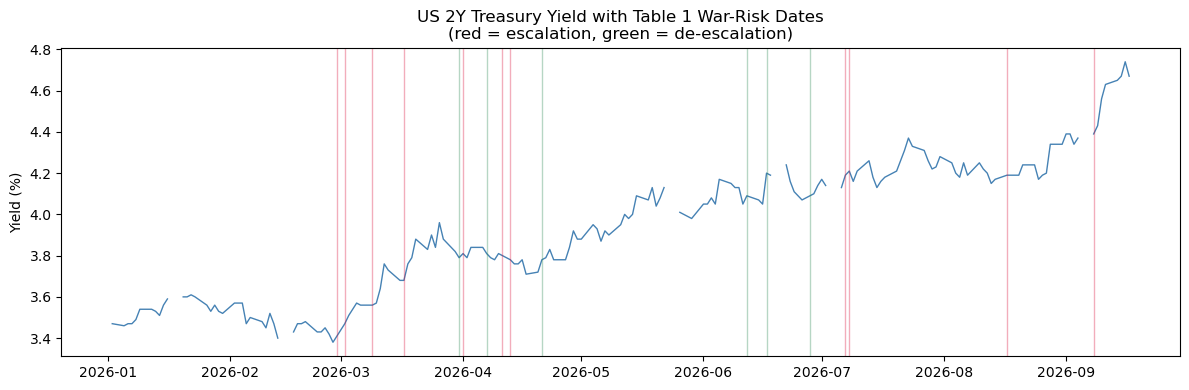

In [18]:
# Plot A: 2Y yield level with Table 1 dates marked
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(levels.index, levels["US2Y_YIELD"], color="steelblue", linewidth=1)
for _, row in table1.iterrows():
    color = "crimson" if row["War Risk"] == "Increased" else "seagreen"
    ax.axvline(row["Date"], color=color, alpha=0.35, linewidth=1)
ax.set_title("US 2Y Treasury Yield with Table 1 War-Risk Dates\n(red = escalation, green = de-escalation)")
ax.set_ylabel("Yield (%)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig1_2y_yield_timeline.png"), dpi=150)
plt.show()


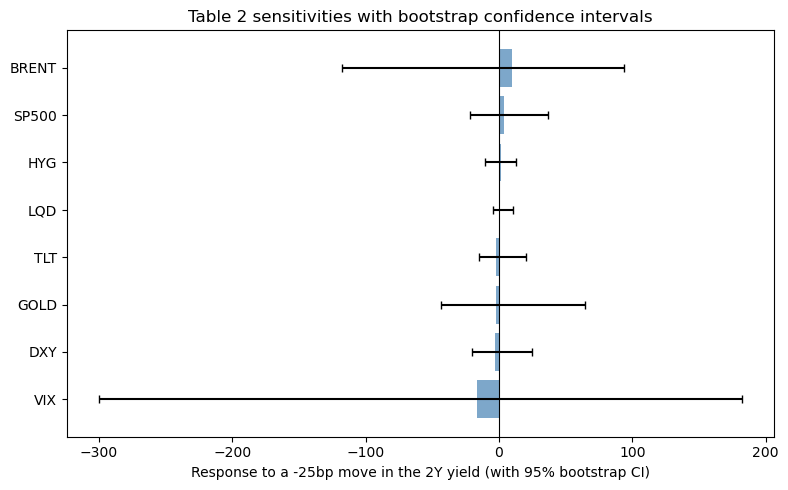

In [19]:
# Plot B: Table 2 responses with bootstrap CI (tornado / error-bar chart)
plot_df = table2_display.sort_values("Response_-25bp_2Y")
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = np.arange(len(plot_df))
colors = ["seagreen" if ~ex else "crimson" for ex in ~plot_df["CI_excludes_zero"]]
ax.barh(y_pos, plot_df["Response_-25bp_2Y"], xerr=[
    plot_df["Response_-25bp_2Y"] - plot_df["CI90_lower"],
    plot_df["CI90_upper"] - plot_df["Response_-25bp_2Y"]
], color="steelblue", alpha=0.7, capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df.index)
ax.set_xlabel("Response to a -25bp move in the 2Y yield (with 95% bootstrap CI)")
ax.set_title("Table 2 sensitivities with bootstrap confidence intervals")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_table2_responses_ci.png"), dpi=150)
plt.show()


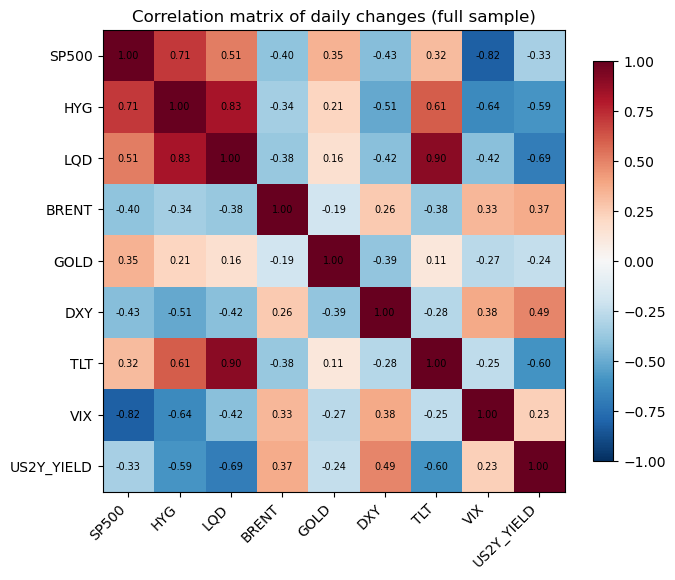

In [20]:
# Plot C: correlation heatmap of daily changes
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix of daily changes (full sample)")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig3_correlation_heatmap.png"), dpi=150)
plt.show()


## 11. Alternative ways to approach war risk (for discussion in the report)

1. **Continuous news-intensity score** (GDELT `TimelineVolRaw`/GKG tone, or a curated news-API feed) used either to binarize high/low days differently, or directly as a regressor in a GARCH-in-mean / EGARCH specification where the conditional variance of the news score predicts asset volatility.
2. **LLM-based headline classification** of daily Iran-related headlines into escalation/de-escalation, producing a cleaner daily score than keyword boolean queries (the fragility that broke the original GDELT-based draft of this notebook).
3. **Options-implied war risk** — oil (OVX) or equity (VIX/skew) implied-vol term-structure kinks around known events, as a forward-looking, market-based risk proxy instead of realized-return heteroskedasticity.
4. **Prediction/event markets** — Kalshi and Polymarket ran Iran-war-related contracts through 2026; their price series is a directly observable, continuous market-implied war-risk factor, sidestepping the whole "war risk is latent" problem that motivates the RS03 estimator in the first place.
5. **Markov-switching / GARCH regime identification** — fit a 2-state variance model to the reference variable and let the high-variance regime be estimated rather than hand-picked, removing the researcher-discretion critique of a manually chosen Table 1.
6. **Event-study / local projections** around each date individually, as a complement to the pooled estimator, to see whether effects are concentrated in a tight window or bleed in gradually — useful here specifically because, unlike RS03's single clean pre-war episode, this sample spans two ceasefire collapses and is likely to have a much less homogeneous "high-risk" regime.

## 12. Notes for the report (not a conclusion — just what the code shows)

- This is analysis of a **different kind of regime** than RS03: an active, 6+-month war with two collapsed ceasefires, not a 10-week pre-war build-up. Whatever the numbers show, that context should frame the write-up rather than being treated as a deviation from an expected replication result.
- Table 3's `Pct_explained_H_days` is a **lower bound** on the war-risk-driven share of variance, by RS03's own derivation — it is not to be read as "the" variance share.
- The bootstrap CIs and the IV first-stage F-statistic are the two honesty checks to lead with in the report: an estimate with a CI that includes zero, or an IV first-stage F well under 10, is a legitimate finding to report as such, not a result to omit.


## 13. Export


In [21]:
table1.to_csv(os.path.join(OUTPUT_DIR, "Table_1_high_war_news_days.csv"), index=False)
table2_display.to_csv(os.path.join(OUTPUT_DIR, "Table_2_war_risk_sensitivities.csv"))
table3.to_csv(os.path.join(OUTPUT_DIR, "Table_3_variance_decomposition.csv"))
comparison.to_csv(os.path.join(OUTPUT_DIR, "Table_2_vs_IV_comparison.csv"))
pairs.to_csv(os.path.join(OUTPUT_DIR, "high_low_matched_pairs.csv"), index=False)
est.to_csv(os.path.join(OUTPUT_DIR, "heteroskedastic_estimates.csv"))
iv_results.to_csv(os.path.join(OUTPUT_DIR, "iv_crosscheck_2sls.csv"))
regime_compare.to_csv(os.path.join(OUTPUT_DIR, "regime_comparison_diagnostics.csv"))
corr.to_csv(os.path.join(OUTPUT_DIR, "correlation_matrix.csv"))
changes.to_csv(os.path.join(OUTPUT_DIR, "market_daily_changes.csv"))

summary = pd.DataFrame({
    "sample_start": [START], "sample_end": [END],
    "market_observations": [len(changes)],
    "high_news_days_in_table1": [len(table1)],
    "matched_pairs_used": [len(pairs)],
    "reference_variable": [REFERENCE],
    "n_bootstrap_draws": [N_BOOT],
})
summary.to_csv(os.path.join(OUTPUT_DIR, "summary.csv"), index=False)
print("Saved all tables, diagnostics, and figures to:", OUTPUT_DIR)
display(summary)


Saved all tables, diagnostics, and figures to: iran_war_risk_2026_outputs


,sample_start,sample_end,market_observations,high_news_days_in_table1,matched_pairs_used,reference_variable,n_bootstrap_draws
0,2026-01-01,2026-09-19,177,17,17,US2Y_YIELD,2000
